### Making the Regression DataSet

In [79]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np


In [80]:
X, y = make_regression(n_samples= 100, n_features=1, n_informative=1, n_targets=1, noise= 20, random_state=13)

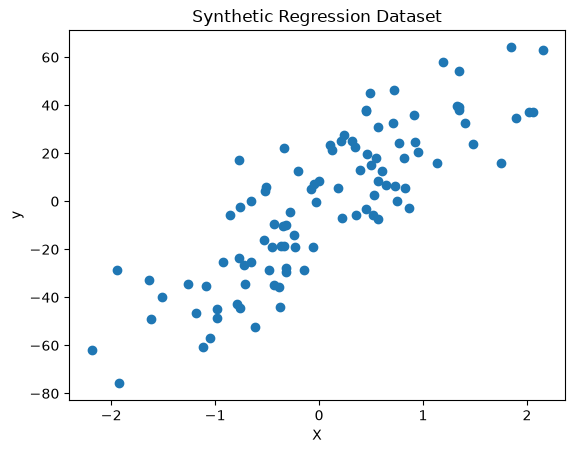

In [81]:
plt.scatter(X, y)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Synthetic Regression Dataset")
plt.show()

In [82]:
# Training the modedl using Linear Regression
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Training the model using Linear Regression
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
print("Model Coefficient:", model.coef_[0])
print("Model Intercept:", model.intercept_)

# Making predictions
y_pred = model.predict(X_test)

from sklearn.metrics import r2_score
print("R-squared score:", r2_score(y_test, y_pred))


Model Coefficient: 28.16404017122941
Model Intercept: -2.7130725669241036
R-squared score: 0.6186926408914155


In [87]:
# Now lets implement the gradient descent algorithm from scratch to train a linear regression model.
# Keeping bot 'm' and 'b' as variable and calculating the loss slope for both 'm' and 'b' and updating them in each iteration.

class GDRegressor:
    def __init__(self, learning_rate, epochs):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.m = 1
        self.b = 0

    def fit(self, X, y):

        for i in range(self.epochs):
            # Calculating the b
            loss_slope_b = -2 * np.sum(y - (self.m * X.ravel() + self.b))

            # Calculating the m
            loss_slope_m = -2 * np.sum(X.ravel() * (y - (self.m * X.ravel() + self.b)))

            self.b = self.b - self.learning_rate * loss_slope_b
            self.m = self.m - self.learning_rate * loss_slope_m
            
        print(self.b)
        print(self.m)

    def predict(self, X):
        return self.m * X + self.b

In [88]:
gd = GDRegressor(learning_rate=0.0001, epochs=10000)

In [89]:
gd.fit(X_train, y_train)

-2.713072566924087
28.16404017122929


In [90]:
y_pred_gd = gd.predict(X_test)
print("R-squared score for GD:", r2_score(y_test, y_pred_gd))

R-squared score for GD: 0.618692640891416


### We can see that the R2 Score for our model using Linear Regression and using Gradient Descent is almost the same 
# Hence we implemented the Gradient Descent for both variables here. 